In [1]:
import numpy as np
import pandas as pd
from numba import njit
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2
# Suppress scientific notation for floats
np.set_printoptions(suppress=True)
# Configure rng
RNG = np.random.default_rng()

In [3]:
# parameters
THETA_NAMES = ("Learning rate", "Sensitivity")
THETA_LABELS= (r"$\alpha$", r"$\tau$")
ETA_NAMES = ("Transition scale", "Transition scale", "Transition slope", "Transition slope")
ETA_LABELS= (r"$\sigma_{\alpha}$", r"$\sigma_{\tau}$", r"$\beta_{\alpha}$", r"$\beta_{\tau}$")

# plotting
FONT_SIZE_1 = 22
FONT_SIZE_2 = 18
FONT_SIZE_3 = 16

## Helpers

In [122]:
import math
@njit
def norm_cdf(x):
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

## Prior

In [157]:
@njit
def sample_group_eta():
    mu_std_alpha = np.random.normal(-2.5, 0.4)
    sig_std_alpha = np.abs(np.random.normal(0, 0.2))
    mu_beta_alpha = np.random.normal(1, 0.1)
    sig_beta_alpha = np.abs(np.random.normal(0, 0.1))
    mu_std_tau = np.random.normal(-2, 1.5)
    sig_std_tau = np.abs(np.random.normal(0, 0.5))
    mu_beta_tau = np.random.normal(1, 0.1)
    sig_beta_tau = np.abs(np.random.normal(0, 0.1))
    return np.array([
        mu_std_alpha, sig_std_alpha, mu_beta_alpha, sig_beta_alpha,
        mu_std_tau, sig_std_tau, mu_beta_tau, sig_beta_tau
    ])

# @njit
def sample_eta(group_eta, num_sub):
    eta = np.zeros((num_sub, 4))
    for i in range(num_sub):
        eta[i, 0] = norm_cdf(np.random.normal(group_eta[0], group_eta[1]))
        eta[i, 1] = np.random.normal(group_eta[2], group_eta[3])
        eta[i, 2] = np.log(1 + np.exp(np.random.normal(group_eta[4], group_eta[5])))
        eta[i, 3] = np.random.normal(group_eta[6], group_eta[7])
    return eta

@njit
def sample_theta_0():
    alpha = np.random.beta(a=1.5, b=2)
    tau = np.random.beta(1, 2) * 8
    return np.array([alpha, tau])


@njit
def sample_ar1(eta, num_steps=200):
    lower_bounds = np.array([0, 0])
    upper_bounds = np.array([1, 8])
    theta = np.zeros((num_steps, 2))
    theta[0] = sample_theta_0()
    z = np.random.randn(num_steps - 1, 2)
    for t in range(1, num_steps):
        theta[t] = np.minimum(
            np.maximum(
                eta[2:] * theta[t - 1] + eta[:2] * z[t - 1], lower_bounds
            ),
            upper_bounds
        )
    return theta

In [178]:
group_eta = sample_group_eta()
eta = sample_eta(group_eta, 500)
eta

array([[0.0083812 , 1.04595507, 0.49221427, 0.71861024],
       [0.00684141, 0.81992451, 1.0734394 , 1.02014129],
       [0.00732272, 0.87580605, 0.15788653, 0.49851164],
       ...,
       [0.00920109, 1.05085976, 0.02581537, 0.5615571 ],
       [0.00737586, 1.0574309 , 0.05165386, 0.64130546],
       [0.00919898, 1.01336588, 0.15300775, 0.60146588]])

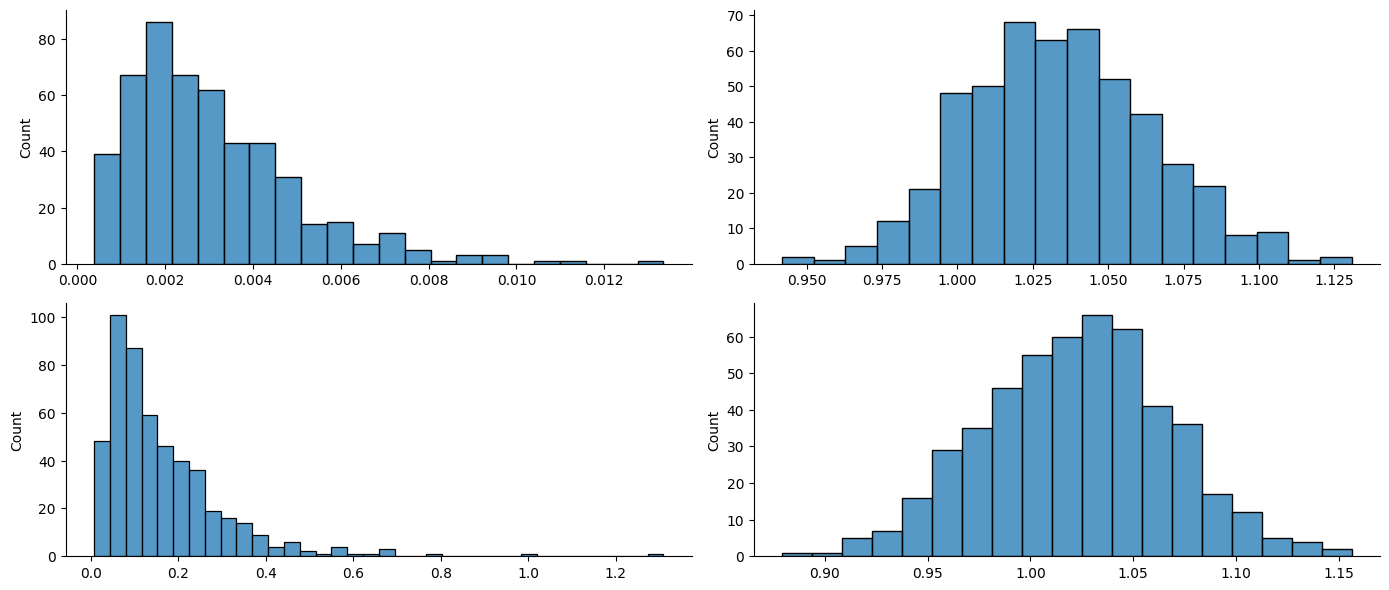

In [187]:
group_eta = sample_group_eta()
eta = sample_eta(group_eta, 500)
fig, axarr = plt.subplots(2, 2, figsize=(14, 6))
for i, ax in enumerate(axarr.flat):
    sns.histplot(eta[:, i], ax=ax)
sns.despine()
fig.tight_layout()